## ML analysis with sif, ppt, tmean, tdmean, original NEE

In [2]:
import pandas as pd
import numpy as np
import sklearn

In [3]:
nee_compare = pd.read_csv('../../gis/output/statistics/msa_mean_compare.csv')

# Extract columns for downscaled and original datasets
downscaled_cols = ['NAMELSAD'] + [col.replace("nee_downscaled_msa_mean_", "") for col in nee_compare.columns if "nee_downscaled_msa_mean_" in col]
orig_cols = ['NAMELSAD'] + [col.replace("nee_orig_msa_mean_", "") for col in nee_compare.columns if "nee_orig_msa_mean_" in col]

# Create separate DataFrames
downscaled_nee_stats = nee_compare[['NAMELSAD'] + [f"nee_downscaled_msa_mean_{col}" for col in downscaled_cols[1:]]].rename(columns=lambda x: x.replace("nee_downscaled_msa_mean_", "") if "nee_downscaled_msa_mean_" in x else x)
orig_nee_stats = nee_compare[['NAMELSAD'] + [f"nee_orig_msa_mean_{col}" for col in orig_cols[1:]]].rename(columns=lambda x: x.replace("nee_orig_msa_mean_", "") if "nee_orig_msa_mean_" in x else x)

downscaled_nee_stats.rename({'NAMELSAD': 'msa'}, axis=1, inplace=True)
orig_nee_stats.rename({'NAMELSAD': 'msa'}, axis=1, inplace=True)

In [4]:
uniq_states = set()
for msa in orig_nee_stats['msa']:
    state = msa.split(", ")[1]
    uniq_states.add(state[:-11]) 
uniq_states

{'AL',
 'AR',
 'AR-OK',
 'AZ',
 'CA',
 'CO',
 'CT',
 'DC-VA-MD-WV',
 'DE',
 'FL',
 'GA',
 'GA-AL',
 'GA-SC',
 'IA',
 'IA-IL',
 'IA-NE-SD',
 'ID',
 'ID-WA',
 'IL',
 'IL-IN',
 'IN',
 'IN-MI',
 'KS',
 'KY',
 'KY-IL',
 'KY-IN',
 'LA',
 'MA',
 'MA-NH',
 'MD',
 'MD-WV',
 'ME',
 'MI',
 'MN',
 'MN-WI',
 'MO',
 'MO-IL',
 'MO-KS',
 'MS',
 'MT',
 'NC',
 'NC-SC',
 'ND-MN',
 'NE',
 'NH',
 'NJ',
 'NM',
 'NV',
 'NY',
 'NY-NJ',
 'OH',
 'OH-KY-IN',
 'OK',
 'OR',
 'OR-WA',
 'PA',
 'PA-NJ',
 'PA-NJ-DE-MD',
 'RI-MA',
 'SC',
 'TN',
 'TN-GA',
 'TN-KY',
 'TN-MS-AR',
 'TN-VA',
 'TX',
 'TX-AR',
 'UT',
 'UT-ID',
 'VA',
 'VA-NC',
 'VA-WV',
 'VT',
 'WA',
 'WI',
 'WV',
 'WV-KY-OH',
 'WV-OH'}

In [5]:
regions = {
    'northeast': ['CT', 'MA', 'MA-NH', 'MD', 'MD-WV', 'ME', 'NH', 'NJ', 'NY', 'NY-NJ', 'PA', 'PA-NJ', 'PA-NJ-DE-MD', 'RI-MA', 'VT'],
    'southeast': ['AL', 'AR', 'DC-VA-MD-WV', 'DE', 'FL', 'GA', 'GA-AL', 'GA-SC', 'KY', 'KY-IL', 'KY-IN', 'MD', 'MD-WV', 'NC', 'NC-SC', 'SC', 'TN', 'TN-GA', 'TN-KY', 'TN-MS-AR', 'TN-VA', 'VA', 'VA-NC', 'VA-WV', 'WV', 'WV-KY-OH', 'WV-OH', 'MS', 'LA'],
    'midwest': ['IA', 'IA-IL', 'IA-NE-SD', 'IL', 'IL-IN', 'IN', 'IN-MI', 'KS', 'MI', 'MN', 'MN-WI', 'MO', 'MO-IL', 'MO-KS', 'ND-MN', 'NE', 'OH', 'OH-KY-IN', 'WI'],
    'interior': ['CO', 'ID', 'ID-WA', 'KS', 'MT', 'ND-MN', 'NE', 'NM', 'IA-NE-SD', 'OK', 'TX', 'TX-AR', 'UT', 'UT-ID', 'AR-OK'],
    'west_coast': ['CA', 'NV', 'OR', 'OR-WA', 'WA'],
    'southwest': ['AZ', 'NM', 'NV', 'TX']
}

# Check if regions have correctly classify those states
for states in regions.values():
    for s in states:
        if s not in uniq_states:
            print(s)
flattened_regions = [state for sublist in regions.values() for state in sublist]
for state in uniq_states:
    if state not in flattened_regions:
        print(state)
        
# Flatten the list of states in regions
all_region_states = set([state for sublist in regions.values() for state in sublist])

# Check if all values in uniq_states are included in regions
all_included = uniq_states.issubset(all_region_states)
print(all_included)

True


In [8]:
ppt_stats = pd.read_csv('../../data/statistics/prism_msa_mean/ppt_msa_mean_2001-2015.csv')
tmean_stats = pd.read_csv('../../data/statistics/prism_msa_mean/tmean_msa_mean_2001-2015.csv')
tdmean_stats = pd.read_csv('../../data/statistics/prism_msa_mean/tdmean_msa_mean_2001-2015.csv')
sif_stats = pd.read_csv('../../data/statistics/green_indices_stats/sif_msa_mean.csv')

ppt_stats.rename({'Unnamed: 0': 'msa'}, axis=1, inplace=True)
tmean_stats.rename({'Unnamed: 0': 'msa'}, axis=1, inplace=True)
tdmean_stats.rename({'Unnamed: 0': 'msa'}, axis=1, inplace=True)
sif_stats.rename({'Unnamed: 0': 'msa'}, axis=1, inplace=True)


ppt_stats = ppt_stats.rename(columns={col: f"{col}_ppt" for col in ppt_stats.columns if col != "msa"})
tmean_stats = tmean_stats.rename(columns={col: f"{col}_tmean" for col in tmean_stats.columns if col != "msa"})
tdmean_stats = tdmean_stats.rename(columns={col: f"{col}_tdmean" for col in tdmean_stats.columns if col != "msa"})
sif_stats = sif_stats.rename(columns={col: f"{col}_sif" for col in sif_stats.columns if col != "msa"})
orig_nee_stats = orig_nee_stats.rename(columns={col: f"{col}_nee" for col in orig_nee_stats.columns if col != "msa"})

# Merge datasets on 'msa' column
df = ppt_stats.merge(tmean_stats, on="msa") \
              .merge(tdmean_stats, on="msa") \
              .merge(sif_stats, on="msa") \
              .merge(orig_nee_stats, on="msa")

df_long = df.melt(id_vars=['msa'], var_name='time', value_name='value')

# Separate target (NEE) and predictors
df_long['variable'] = df_long['time'].str.split('_').str[-1] 
df_long['time'] = df_long['time'].str.split('_').str[0]  

# Pivot table
df_pivot = df_long.pivot_table(index=['msa', 'time'], columns='variable', values='value').reset_index()

In [41]:
df_pivot

variable,msa,time,nee,ppt,sif,tdmean,tmean
0,"Abilene, TX Metro Area",200101,0.090349,41.225386,209.872659,-0.562452,4.687913
1,"Abilene, TX Metro Area",200102,-0.014621,74.936502,457.696629,3.188889,8.588515
2,"Abilene, TX Metro Area",200103,-0.173455,55.923560,1100.501873,3.851553,9.793486
3,"Abilene, TX Metro Area",200104,-0.686147,22.863401,2080.161049,10.829077,17.953254
4,"Abilene, TX Metro Area",200105,-0.263033,74.824850,1418.014981,14.146118,23.122622
...,...,...,...,...,...,...,...
64975,"Yuma, AZ Metro Area",201508,0.224677,6.447885,75.521978,13.166476,34.542191
64976,"Yuma, AZ Metro Area",201509,0.178707,22.917854,106.750916,13.199502,31.003187
64977,"Yuma, AZ Metro Area",201510,0.056729,15.970642,96.626374,9.162636,25.334064
64978,"Yuma, AZ Metro Area",201511,-0.035191,2.881659,26.549451,-3.402125,15.358903


In [ ]:
# # Scale x variables
# from sklearn.preprocessing import StandardScaler

# # Initialize the scaler
# scaler = StandardScaler()

# # Scale the specified columns
# df_pivot[['ppt', 'sif', 'tdmean', 'tmean']] = scaler.fit_transform(df_pivot[['ppt', 'sif', 'tdmean', 'tmean']])

### Fit ML Model for different regions

In [9]:
# Import libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import warnings
import random

from scipy.integrate import odeint
from IPython.display import Image

# Sklearn specific functions used in this lecture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree
from sklearn.metrics import mean_squared_error, r2_score


# Suppress warnings
warnings.filterwarnings('ignore')

# Set number of decimals for np print options
np.set_printoptions(precision=3)


#### Prepare dataset for each region

In [10]:
import re
def get_region(msa_name):
    pattern = r",\s([^,]+)\sMetro Area$"
    state = re.search(pattern, msa_name).group(1)
    for region, states in regions.items():
        if state in states:
            return region

df_pivot["region"] = df_pivot["msa"].apply(get_region)

In [14]:
import geopandas as gpd
# Load the dataset
msa_file = '../../gis/msa/msaUS_mland_aea1_M1.shp'
msa_gdf_crsaea = gpd.read_file(msa_file)


In [16]:
msa_gdf_crsaea['region'] = msa_gdf_crsaea['NAMELSAD'].apply(get_region)

In [17]:
msa_gdf_crsaea

,NAMELSAD,GEOIDFQ,AWATER,GEOID,LSAD,CBSAFP,ALAND,CSAFP,NAME,geometry,region
0,"College Station-Bryan, TX Metro Area",310M700US17780,8.658677e+07,17780,M1,17780,5.439947e+09,None,"College Station-Bryan, TX","POLYGON ((-92248.327 831713.461, -90462.598 83...",interior
1,"Grand Forks, ND-MN Metro Area",310M700US24220,7.765817e+07,24220,M1,24220,8.824671e+09,None,"Grand Forks, ND-MN","POLYGON ((-143180.617 2781900.583, -143019.146...",midwest
2,"Sebring, FL Metro Area",310M700US42700,2.306679e+08,42700,M1,42700,2.635727e+09,None,"Sebring, FL","POLYGON ((1429995.959 587637.566, 1429330.704 ...",southeast
3,"Toledo, OH Metro Area",310M700US45780,6.767839e+08,45780,M1,45780,3.528279e+09,None,"Toledo, OH","MULTIPOLYGON (((955964.693 2136422.334, 956209...",midwest
4,"Eagle Pass, TX Metro Area",310M700US20580,3.186297e+07,20580,M1,20580,3.313828e+09,None,"Eagle Pass, TX","POLYGON ((-454671.607 679032.747, -450615.826 ...",interior
...,...,...,...,...,...,...,...,...,...,...,...
356,"Baltimore-Columbia-Towson, MD Metro Area",310M700US12580,1.304184e+09,12580,M1,12580,6.737775e+09,548,"Baltimore-Columbia-Towson, MD","MULTIPOLYGON (((1579233.819 2002200.222, 15792...",northeast
357,"Wausau, WI Metro Area",310M700US48140,8.065307e+07,48140,M1,48140,4.002034e+09,554,"Wausau, WI","POLYGON ((448654.989 2435368.152, 448519.565 2...",midwest
358,"Wichita, KS Metro Area",310M700US48620,8.594755e+07,48620,M1,48620,1.074363e+10,556,"Wichita, KS","POLYGON ((-158036.253 1624741.008, -157878.199...",midwest
359,"Williamsport, PA Metro Area",310M700US48700,3.891758e+07,48700,M1,48700,3.182887e+09,558,"Williamsport, PA","POLYGON ((1514264.517 2206191.218, 1514172.239...",northeast


In [ ]:
msa_gdf_crsaea.to_file("../../gis/msa/region/msa_region.shp", driver="ESRI Shapefile")

In [44]:
x_vars = ['ppt', 'tmean', 'tdmean', 'sif']
y_var = 'nee'

selected_region = 'northeast'
dataset_region = {}
for region in regions.keys():
    df_filtered = df_pivot[df_pivot["region"] == region]
    X_region = df_filtered[x_vars]
    y_region = df_filtered[y_var]
    # dataset_region[region] = (X_region, y_region)

    random.seed(42)
    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_region, y_region, test_size=0.2, random_state=42)
    dataset_region[region] = (X_train, X_test, y_train, y_test)

In [45]:
X_train

variable,ppt,tmean,tdmean,sif
31023,12.562896,14.695842,-5.381770,166.191273
44974,60.825705,16.064786,0.985499,161.195814
58746,92.303894,30.881263,13.213470,286.450720
30979,1.957655,28.491425,0.144017,-33.629818
31050,22.698013,29.033443,6.847814,199.039273
...,...,...,...,...
58824,21.494851,8.539079,-6.444274,56.058693
64815,0.000000,21.778921,0.385168,20.364469
64850,6.266396,16.052878,2.345036,423.912088
53960,42.449437,22.240412,7.369399,442.001623


#### Decision Tree Regressor for all regions

In [28]:
import shap

In [30]:
folder_name = '../../figures/ml_sif_region_scaled'

--- Region: northeast, Training sample size: 7632 ---
Feature importance: [0.016 0.03  0.026 0.929]
Mean Squared Error: 0.24958251059402278
R-squared: 0.893939210550157
--- Region: southeast, Training sample size: 17568 ---
Feature importance: [0.022 0.032 0.032 0.914]
Mean Squared Error: 0.18345310087157146
R-squared: 0.845264572487597
--- Region: midwest, Training sample size: 11808 ---
Feature importance: [0.021 0.033 0.028 0.918]
Mean Squared Error: 0.17102000400722167
R-squared: 0.8676789983532838
--- Region: interior, Training sample size: 7200 ---
Feature importance: [0.042 0.062 0.266 0.63 ]
Mean Squared Error: 0.09235055876278299
R-squared: 0.7489396429093795
--- Region: west_coast, Training sample size: 6768 ---
Feature importance: [0.019 0.032 0.037 0.912]
Mean Squared Error: 0.08952682060165795
R-squared: 0.8722815032822882
--- Region: southwest, Training sample size: 1008 ---
Feature importance: [0.05  0.44  0.053 0.456]
Mean Squared Error: 0.010889642938718096
R-squared: 

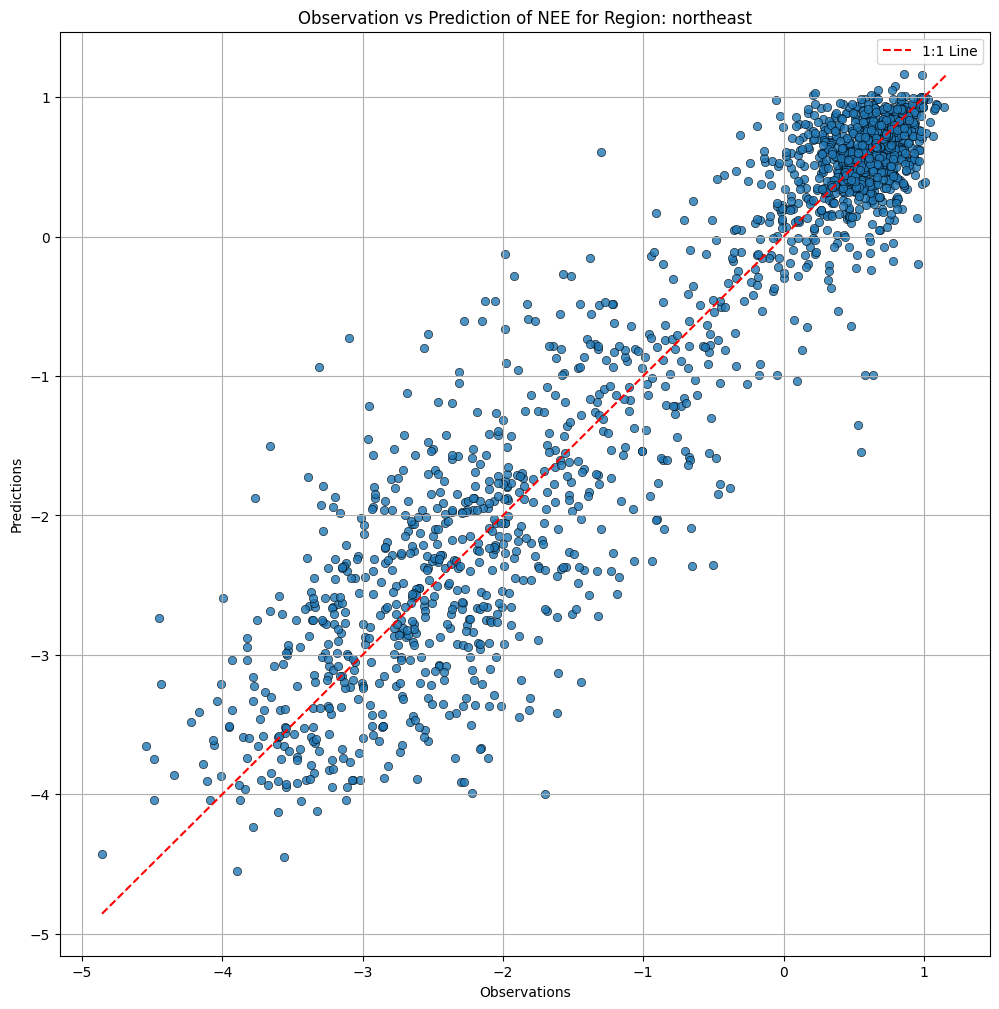

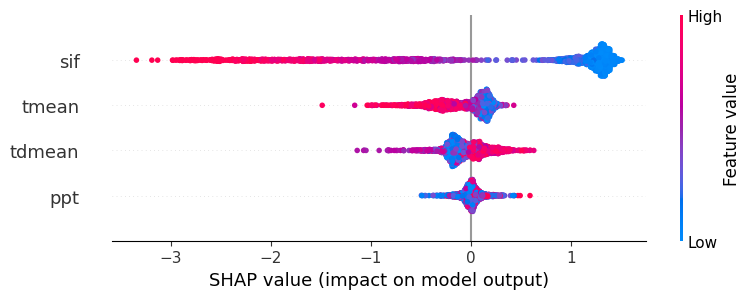

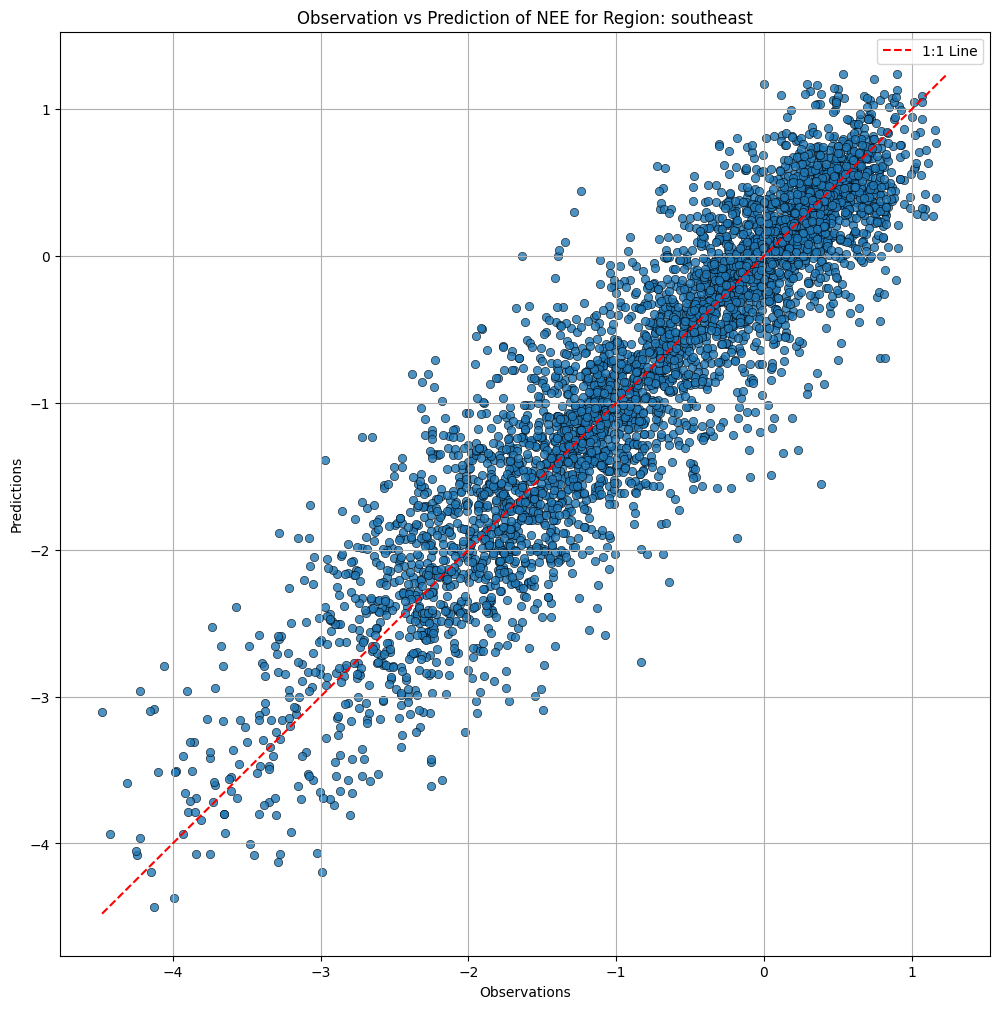

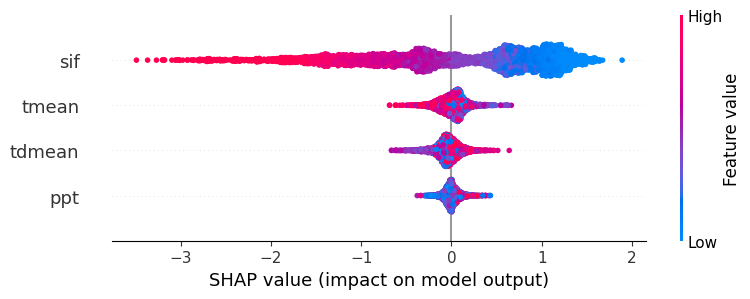

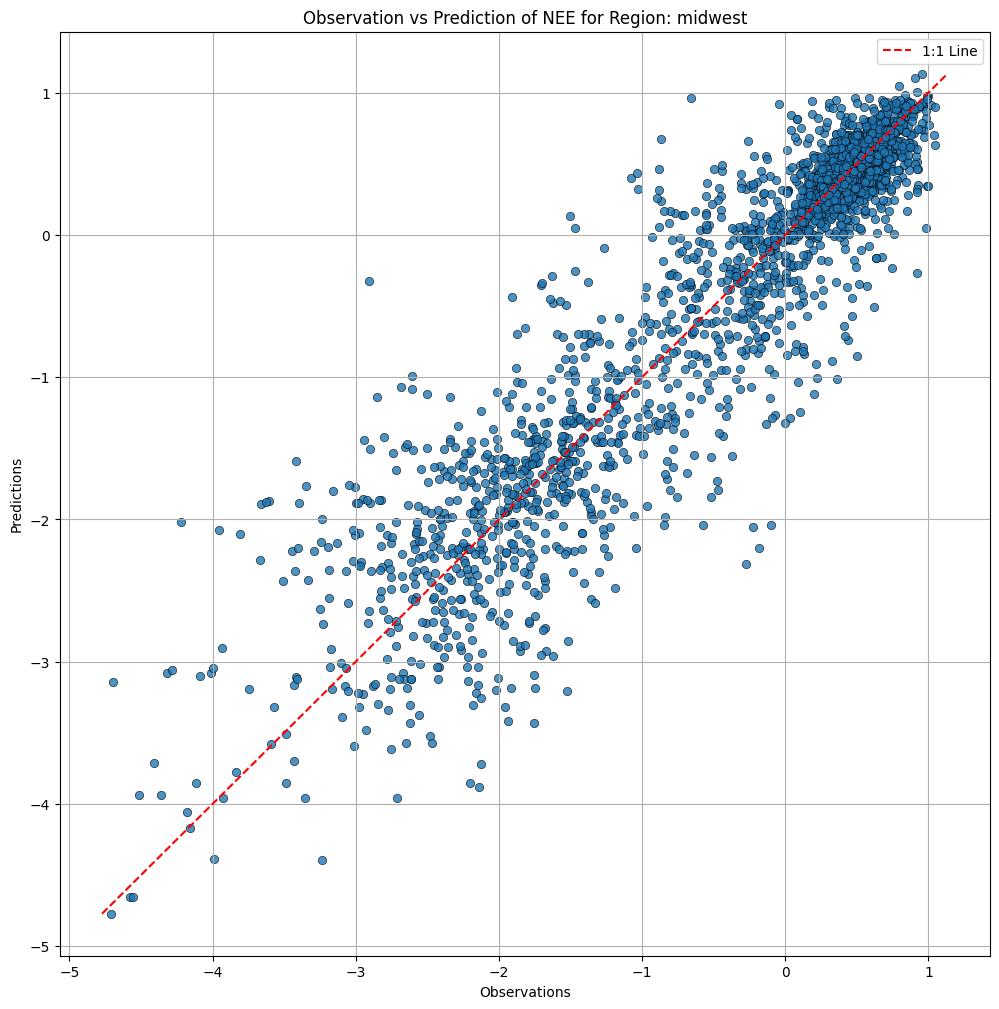

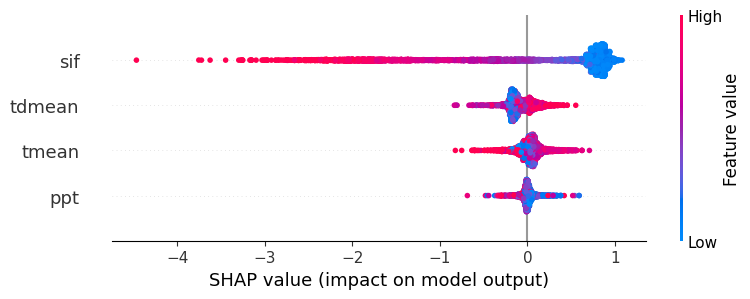

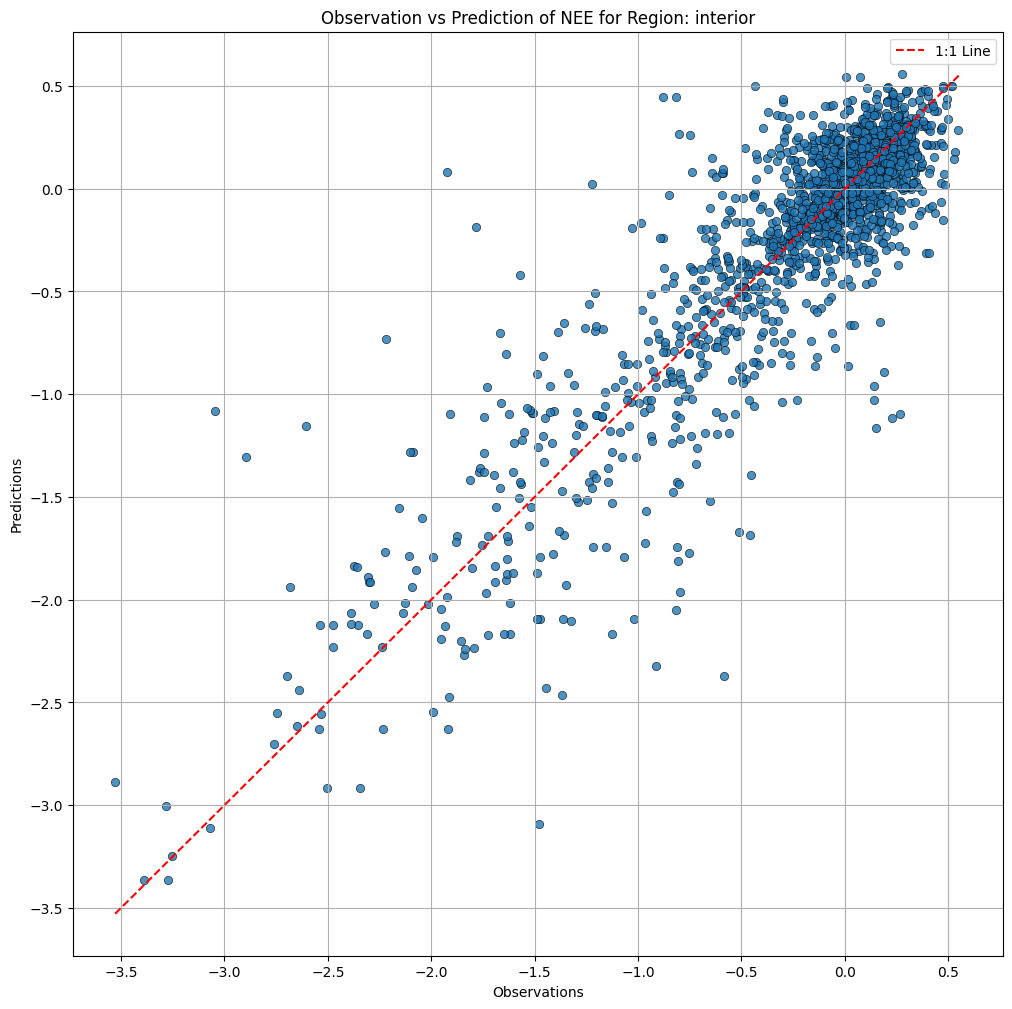

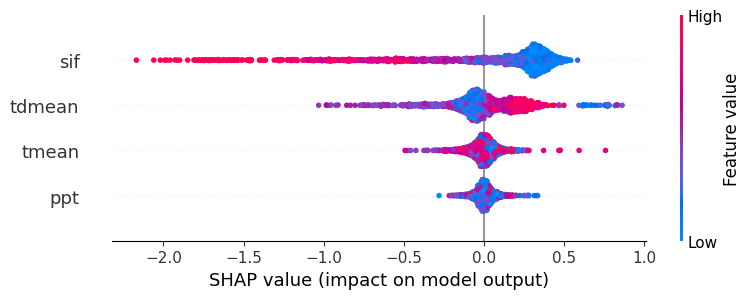

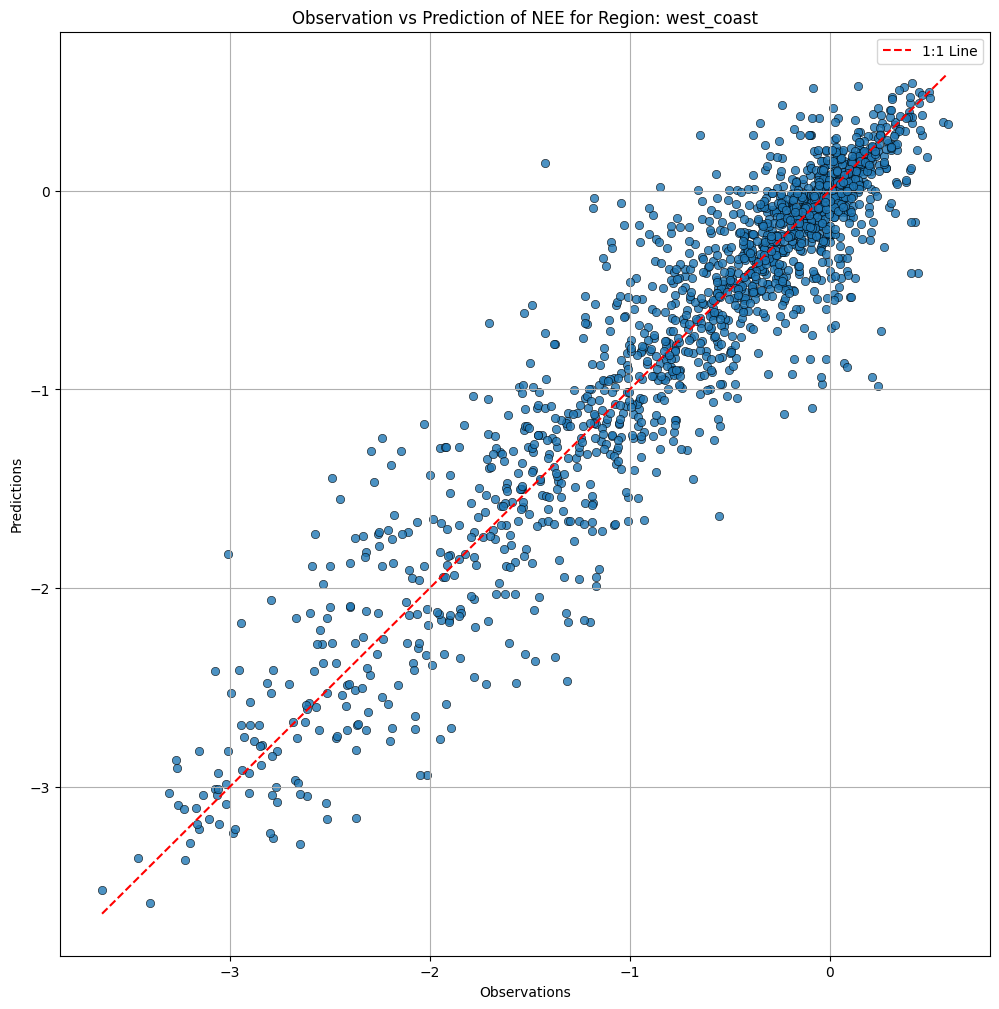

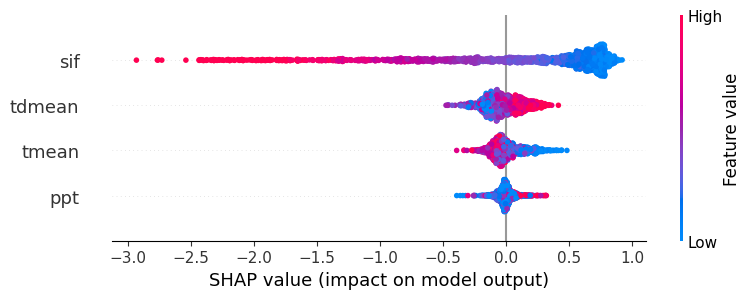

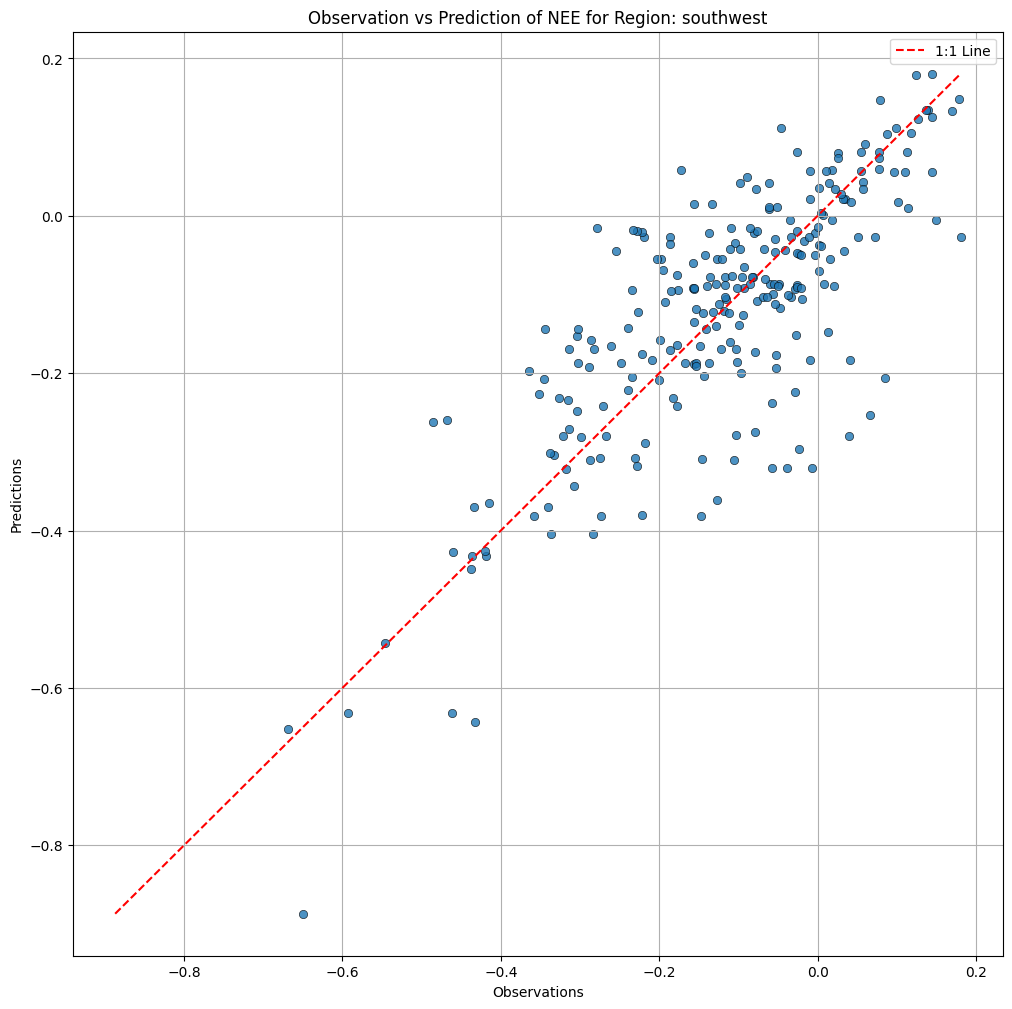

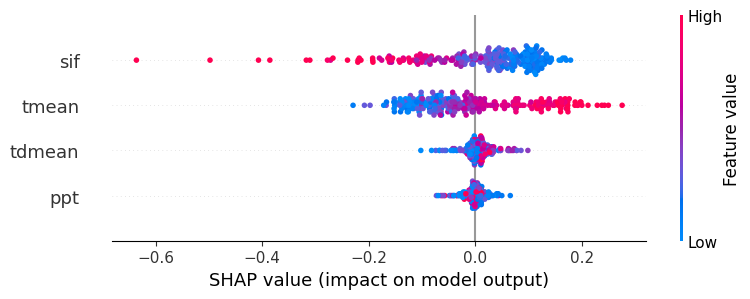

In [46]:
for region in dataset_region.keys():
    print(f"--- Region: {region}, Training sample size: {len(dataset_region[region][0])} ---")
    X_train, X_test, y_train, y_test = dataset_region[region]
    
    # Initialize the Decision Tree Regressor
    regressor = DecisionTreeRegressor(random_state=42)

    # Train the regressor
    regressor.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = regressor.predict(X_test)

    results = pd.DataFrame(np.column_stack((y_pred,y_test)), columns= ['y_pred', 'y_test'])

    # Create scatter plot
    plt.figure(figsize=(12, 12))
    sns.scatterplot(data=results, x="y_test", y="y_pred", alpha=0.8, edgecolor="black")

    plt.xlabel('Observations')
    plt.ylabel('Predictions')
    plt.title(f'Observation vs Prediction of NEE for Region: {region}')

    # Plot the one-to-one line (y = x)
    min_val = min(results["y_test"].min(), results["y_pred"].min())
    max_val = max(results["y_test"].max(), results["y_pred"].max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='1:1 Line')

    plt.legend()
    plt.grid(True)

    # Save the scatter plot
    # scatter_plot_path = f"{folder_name}/nee_ml_obs_vs_pred_{region}.png"
    # plt.savefig(scatter_plot_path, dpi=300)
    # plt.close()  # Close plot to free memory

    print(f"Feature importance: {regressor.feature_importances_}")

    plt.figure(figsize=(6, 6))
    explainer = shap.TreeExplainer(regressor)
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test, show=False)  # Prevent auto-show
    # shap_plot_path = f"{folder_name}/nee_shap_{region}.png"
    # plt.savefig(shap_plot_path, dpi=300)
    # plt.close()

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Mean Squared Error: {mse}")
    print(f"R-squared: {r2}")

    # # Plot the regression tree
    # plt.figure(figsize=(25, 12))
    # plot_tree(regressor, 
    #         feature_names=x_vars,  # Names of the features
    #         filled=True,  # Fills nodes with color based on the output
    #         rounded=True,  # Rounds the node boxes
    #         fontsize=6)  # Font size for readability


### Sensitivity Analysis

In [32]:
X_train, X_test, y_train, y_test = dataset_region['northeast']

In [33]:
X_train

variable,ppt,tmean,tdmean,sif
41875,-0.085859,0.873830,0.995445,1.863159
33086,-0.468309,-1.369795,-1.374173,-0.942544
801,0.700386,-0.085392,0.187715,-0.086173
4383,-0.422468,-0.513848,-0.483982,-0.701959
64414,-0.314121,-0.870123,-0.976988,-0.792026
...,...,...,...,...
41374,-0.099653,-0.806060,-0.916001,-0.847542
33271,0.531070,0.981115,1.230520,1.293631
35810,-0.672121,-1.722172,-1.830711,-0.949749
3200,0.009382,0.711116,0.871003,0.278501


In [34]:
X_test["sif"].describe()

count    1908.000000
mean        0.156750
std         1.223998
min        -1.118984
25%        -0.945877
50%        -0.358840
75%         1.230553
max         3.047089
Name: sif, dtype: float64

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Define sigma shift values (perturbation levels)
sigma_levels = [-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]  # Adjust as needed

# Iterate through each region in the dataset
for region in list(dataset_region.keys())[:]:
    print(f"--- Region: {region} ---")

    # Extract train-test split data
    X_train, X_test, y_train, y_test = dataset_region[region]

    sigma = X_test["sif"].std()  # Standard deviation of SIF feature
    print(f"Standard Deviation of sif in test dataset: {sigma}")
    print(f'Mean of sif in test dataset: {X_test["sif"].mean()}')

    # Plot histogram of SIF values in X_test
    plt.figure(figsize=(8, 6))
    sns.histplot(X_test["sif"], bins=30, color='blue', edgecolor='black')

    plt.xlabel("SIF Values")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of SIF in Testing Dataset: {region}")
    plt.grid(True)
    # plt.show()
    hist_path = f"{folder_name}/sif_histogram_{region}.png"
    plt.savefig(hist_path, dpi=300)
    plt.close()  # Close plot to free memory

    # Initialize and train Decision Tree model
    regressor = DecisionTreeRegressor(random_state=42)
    regressor.fit(X_train, y_train)

    # Perform Sensitivity Analysis
    sensitivity_results = []

    for sigma_level in sigma_levels:
        # Shift SIF feature
        X_test_shifted = X_test.copy()
        X_test_shifted["sif"] += sigma * sigma_level  # Apply sigma shift

        # Predict NEE with modified SIF
        y_pred_shifted = regressor.predict(X_test_shifted)

        # Store results
        for pred in y_pred_shifted:
            sensitivity_results.append({"sigma_shift_level": sigma_level, "Prediction": pred})

    # Convert results to DataFrame
    sensitivity_df = pd.DataFrame(sensitivity_results)

    # Compute overall median of predictions
    median_values = sensitivity_df.groupby('sigma_shift_level')["Prediction"].median().reset_index()

    # Create a boxplot to visualize sensitivity
    plt.figure(figsize=(8, 6))
    # sns.boxplot(data=sensitivity_df, x="sigma_shift_level", y="Prediction", width=0.5, color='green')
    boxplot_data = [
        sensitivity_df[sensitivity_df["sigma_shift_level"] == sigma_level]["Prediction"].values
        for sigma_level in sigma_levels
    ]
    plt.boxplot(boxplot_data, positions=sigma_levels, patch_artist=True, widths=0.1)

    # Plot line connecting median values
    plt.plot(median_values["sigma_shift_level"], median_values["Prediction"], marker="o", linestyle="-", color="red", label="Median Trend")
    
    plt.xlabel("SIF Shift Level (Sigma)")
    plt.ylabel("Predicted NEE")
    plt.title(f"Sensitivity Analysis: {region}")
    plt.grid(True)

    # plt.show()  # Display the plot
    boxplot_path = f"{folder_name}/sensitivity_analys_boxplot_{region}.png"
    plt.savefig(boxplot_path, dpi=300)
    plt.close()  # Close plot to free memory



--- Region: northeast ---
Standard Deviation of sif in test dataset: 1.223998322687697
Mean of sif in test dataset: 0.15674960231480944
--- Region: southeast ---
Standard Deviation of sif in test dataset: 0.9523815952100205
Mean of sif in test dataset: 0.30409099604163026
--- Region: midwest ---
Standard Deviation of sif in test dataset: 1.1070148018167856
Mean of sif in test dataset: -0.03816704301163245
--- Region: interior ---
Standard Deviation of sif in test dataset: 0.6783593125666403
Mean of sif in test dataset: -0.3941624696930877
--- Region: west_coast ---
Standard Deviation of sif in test dataset: 0.6113770461572061
Mean of sif in test dataset: -0.3950087556417237
--- Region: southwest ---
Standard Deviation of sif in test dataset: 0.1113704328952968
Mean of sif in test dataset: -0.9500039866296657
